# Tutorial: Metapopulations and Levins Model

#### This tutorial will cover:
#### 1. The motivation and biological interpretation of metapopulations and the Levins model.
#### 2. Both computational and mathematical analysis of this model, including slope fields and equilibrium analysis.

#### Learning Goals:
#### - Interpret characteristics of ecological models with different interpretations of the model variable.
#### - Use computational and analytical techniques to analyse the long-term behaviour of the Levins model.

# Biological Motivation and Metapopulations

#### Most single variable ODE models that have been proposed, model the population as well-mixed, meaning there is no spatial structure present in the model (everywhere there is the same density of individuals). However, most populations have a spatial structure that influences the population dynamics.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Canada_British_Columbia_Density_2016.png/1920px-Canada_British_Columbia_Density_2016.png" width="900"/>
</div>

#### In this tutorial, we will examine a theoretical framework introduced by Richard Levins in 1969 that describes metapopulations as a means for studying spatially structured populations.

#### A metapopulation is simply a collection of subpopulations. We can interpret the subpopulations in a few different ways. We could group the individuals by some specific characteristic (certain gene, disease type, fur colour, etc.). However, in our context, we will consider subpopulations to be spatially distinct regions where the individuals can migrate between the colonies. We construct a model using the latter idea of metapopulations.

![Metapopulations](https://methodsblog.files.wordpress.com/2017/08/blog_figure1_chabanne_distribution.jpg) \
Stephenson, I. Mark-Recapture and Metapopulation Structure: Using Study Design to Minimize Heterogeneity. Methods Blog 2017. 

#### In this model we track the proportion of patches that are occupied by the population. The model does not track the density of the population nor which specific patches are inhabited.

#### We will be using a differential equation to model these subpopulations. We assume subpopulations go extinct at a constant rate $m>0$ (mortality of a subpopulation). Vacant patches can be colonized at a rate proportional to the fraction of occupied patches. The proportionality constant is given by $c>0$ (colonization of a vacant subpopulation). Denoting the fraction of patches occupied by $p=p(t)$ allows us to write the Levins model as $$ \frac{dp}{dt}=cp(1-p)-mp. $$

# Slope Field

#### Choose values for $m$ and $c$ in $(0,3]$, and construct a slope field for our model using the below helper code.

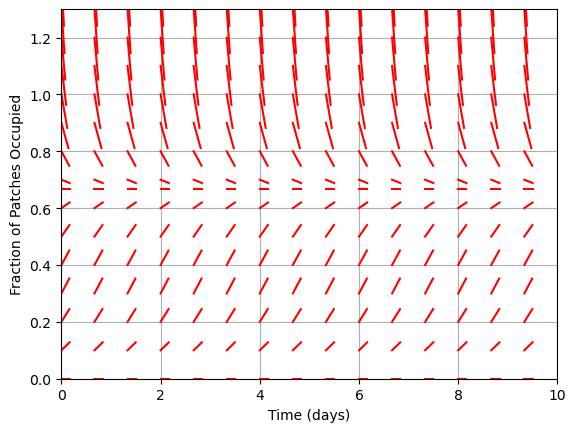

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameter values here
m = 1
c = 3

f = lambda t,p: c*p*(1-p)  - (m*p) # EDIT: Define the RHS of Levins Model
tf = 10; n = 15; L = 0.25*tf/n;
t_grid = np.arange(0,tf,tf/n)
y_grid = np.arange(0,1.5,1.5/n)
if m <= c:
    y_grid = np.append(y_grid, [1-m/c])
# Plot each small slope line at every t_grid, y_grid ordered pair
for t in t_grid: # EDIT: Complete this for loop statement so it loops through all t points
    for y in y_grid: # EDIT: Complete this for loop statement so it loops through all y points
        s = f(t,y)
        theta = np.arctan(s)
        plt.plot([t,t + L*np.cos(theta)],
                 [y,y + L*np.sin(theta)],'r')
plt.xlabel("Time (days)")
plt.ylabel("Fraction of Patches Occupied")
plt.grid(True), plt.xlim([0,tf]), plt.ylim([0,1.3])
plt.savefig("image.svg")
plt.show()



#### Can you find different parameter value combinations that lead to qualitatively different long-term behaviour of the system? (change in stability/number of equilibria)

Equilibrium occurs at 1 - (m/c)

# Equilibria

#### Solve for the equilibria of the Levins model.

0=cp(1-p)-mp

0=-cp+cp^2+mp

0= cp^2 + p (-c + m)

0 = p (cp + (-c + m))


p = 0

0 = cp + (-c + m)

(c - m) / c  = p

1 - (m / c)  = p

#### Are there biological conditions on the existence of these equilibrium points? What is the biological significance of these conditions?

If the mortality is greater than the colonization, it goes to zero. If the mortality is less than the population. 

#### Analyze the stability of the equilibrium point(s). Either with graphical methods or by using derivatives. Make sure you identify the cases for stability and how these relate to the conditions from above.